In [1]:
from pathlib import Path
import matplotlib.pyplot as plt

from src.io import (
    read_eliashberg,
    read_phonon_dos,
    read_electronic_dos,
)

from src.preprocessing import preprocess_aluminum

from src.plotting import (
    plot_eliashberg,
    plot_phonon_dos,
    plot_electronic_dos,
)

In [2]:
# ============================================================
# RUTAS
# ============================================================

BASE_DIR = Path("..")

DATA_DIR = BASE_DIR / "data" / "raw" / "Al"

eliashberg_file = DATA_DIR / "Ala2F.dos1"
phonon_file = DATA_DIR / "Alph.dos"
electronic_file = DATA_DIR / "Aldos.dos"

In [3]:
eliashberg_data = read_eliashberg(eliashberg_file)

phonon_data = read_phonon_dos(phonon_file)

electronic_data = read_electronic_dos(electronic_file)

In [4]:
print("Eliashberg:")
print(f"  Puntos: {len(eliashberg_data['frequency_ry'])}")
print(f"  lambda: {eliashberg_data['lambda']}")
print(f"  Delta:  {eliashberg_data['Delta']}")

print("\nPhonon DOS:")
print(f"  Puntos: {len(phonon_data['frequency_cm1'])}")

print("\nElectronic DOS:")
print(f"  Puntos: {len(electronic_data['energy_ev'])}")
print(f"  EF: {electronic_data['fermi_energy_ev']} eV")

Eliashberg:
  Puntos: 400
  lambda: 0.42528152331612734
  Delta:  7.299508731784537e-06

Phonon DOS:
  Puntos: 400

Electronic DOS:
  Puntos: 644
  EF: 7.931 eV


In [5]:
data = preprocess_aluminum(
    eliashberg_data,
    phonon_data,
    electronic_data,
)

In [6]:
params = data["superconducting_parameters"]

print("PARÁMETROS DEL ALUMINIO")
print("-" * 35)

print(f"E_F       = {params['fermi_energy_ev']:.6f} eV")
print(f"lambda    = {params['lambda']:.6f}")
print(f"Delta QE  = {params['Delta']:.6e}")
print(f"omega_c   = {params['omega_c_mev']:.6f} meV")

PARÁMETROS DEL ALUMINIO
-----------------------------------
E_F       = 7.931000 eV
lambda    = 0.425282
Delta QE  = 7.299509e-06
omega_c   = 39.676242 meV


In [7]:
omega = data["eliashberg"]["frequency_mev"]

a2f = data["eliashberg"]["a2f_total"]

omega_ph = data["phonon"]["frequency_mev"]

nph = data["phonon"]["dos"]

pdos = data["phonon"]["pdos"]

epsilon = data["electronic"]["epsilon_mev"]

ne = data["electronic"]["dos"]

omega_c = data["superconducting_parameters"]["omega_c_mev"]

In [8]:
print(f"ωc = {omega_c:.6f} meV")
print(f"EF = {data['superconducting_parameters']['fermi_energy_ev']:.6f} eV")

ωc = 39.676242 meV
EF = 7.931000 eV


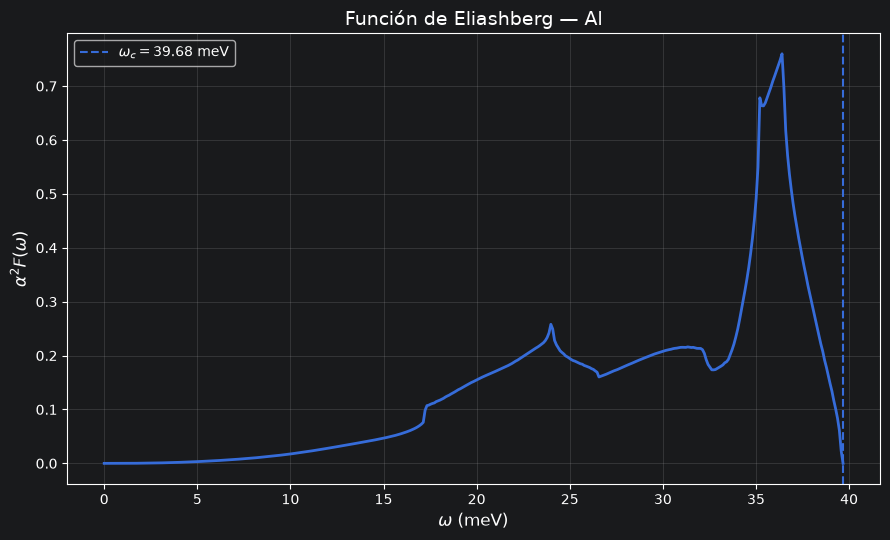

In [9]:
fig, ax = plot_eliashberg(
    omega,
    a2f,
    omega_c,
    material="Al",
)

plt.show()

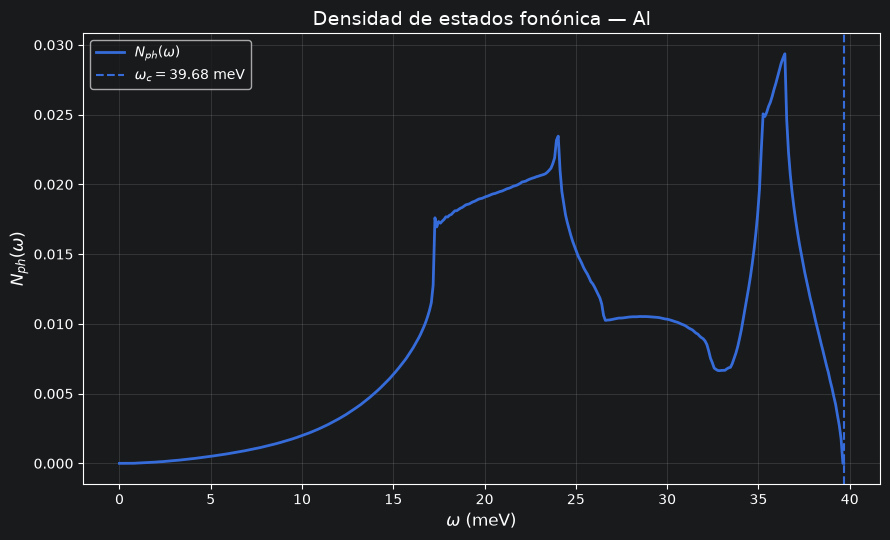

In [10]:
fig, ax = plot_phonon_dos(
    omega_ph,
    nph,
    omega_c,
    material="Al",
)

plt.show()

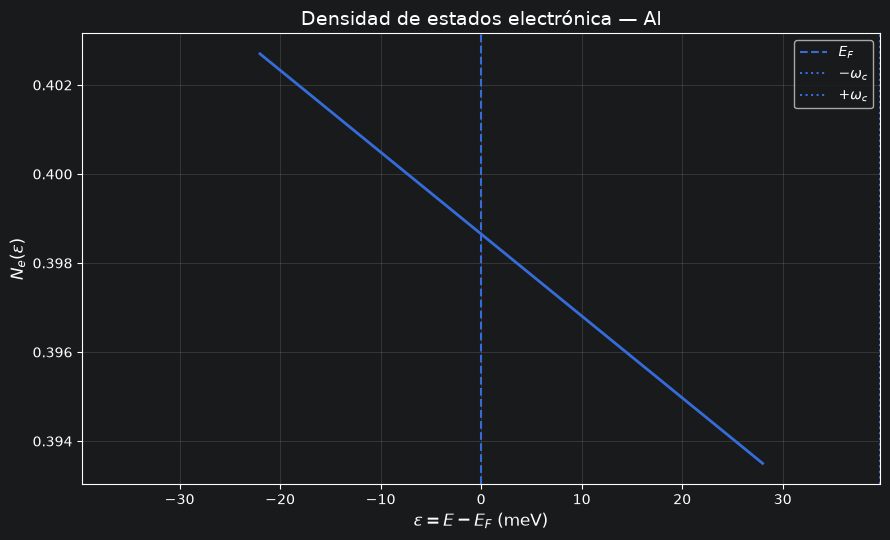

In [11]:
fig, ax = plot_electronic_dos(
    epsilon,
    ne,
    omega_c,
    material="Al",
)

plt.show()